<a href="https://colab.research.google.com/github/sskarthik0801/ME-597-IIOT/blob/main/lab/lab10/PL10_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab10/PL10_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prelab 10.3 Machine Learning 3 - Real-time Sound Recognition for Classification

# Load CNN model on Raspberry Pi

## 3.1 librosa installation on Raspberry Pi

In Lab 10, we will implement sound recognition on Raspberry Pi using the CNN model in the previous section. The librosa package will be used for the feature extraction of the CNN model. Follow the steps below to install librosa on your Raspberry Pi. If you have not installed TensorFlow on Raspberry Pi yet, please go to [Prelab 9.1](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/PL9_Colab1.ipynb) and install it.



1. To install librosa, run the following command on the Terminal of your Raspberry Pi:

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal**

`pip3 install librosa`

---

<br></br>

Now your are ready to use librosa on Raspberry pi. Perform Task 1 to see if librosa is installed successfully on your Raspberry Pi.


### Task 3.1

By running the example Python script below, load librosa and check the version as Figure 12 below and then attach it to the report.



---

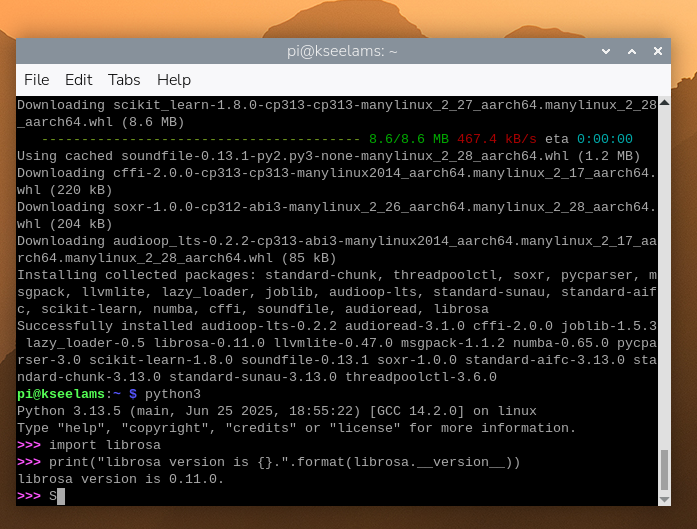

---



**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal & Python**

```
$ python3
>>> import librosa
>>> print(“librosa version is {}.”.format(librosa.__version__))
```

---

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_update/Prelab10_fig12.png?raw=true" width="50%">

*Figure 12 librosa version check (0.11.1)*

## 3.2 Load CNN model on Raspberry Pi

Let's load and test the CNN model which you finally developed on Raspberry Pi. Please follow the steps below.

<br>

  1. Create a working directory which your model and Python file will be in.
     
     a. The directory example (full path): ‘/home/pi/prelab10’

  2. Copy and paste your final model binary file (*.h5 format) in the previous section to the directory (‘/home/pi/prelab10’ in this example).
     
     a. In this example, the model filename is '*20230306_043352_Prelab10_CNN_model1.h5*'.
  
  3. Create a Python file as 'prelab10_load_model.py' on the same directory.


<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/prelab10_img3.png?raw=true" width="70%">


  4. Code the Python script below in the created Python file ('prelab10_load_model.py') and then save it.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python3 (prelab10_load_model.py)**

```
import tensorflow as tf

model = tf.keras.models.load_model('20230306_043352_Prelab10_CNN_model1.h5',  compile=False) # load your model

print(model.summary()) # print out model (CNN) summary

```

---

Now, you are ready to use the model you created in Lab 10. Perform Task 3.2 below to see if the model is loaded successfully on your Raspberry Pi.


### Task 3.2

  1. After performing the stpes above, run the Python file. Is the result as you expected?

  2. Capture the result of Terminal or Thonny Shell as Figure 13 and attach it to the report.

    ---

   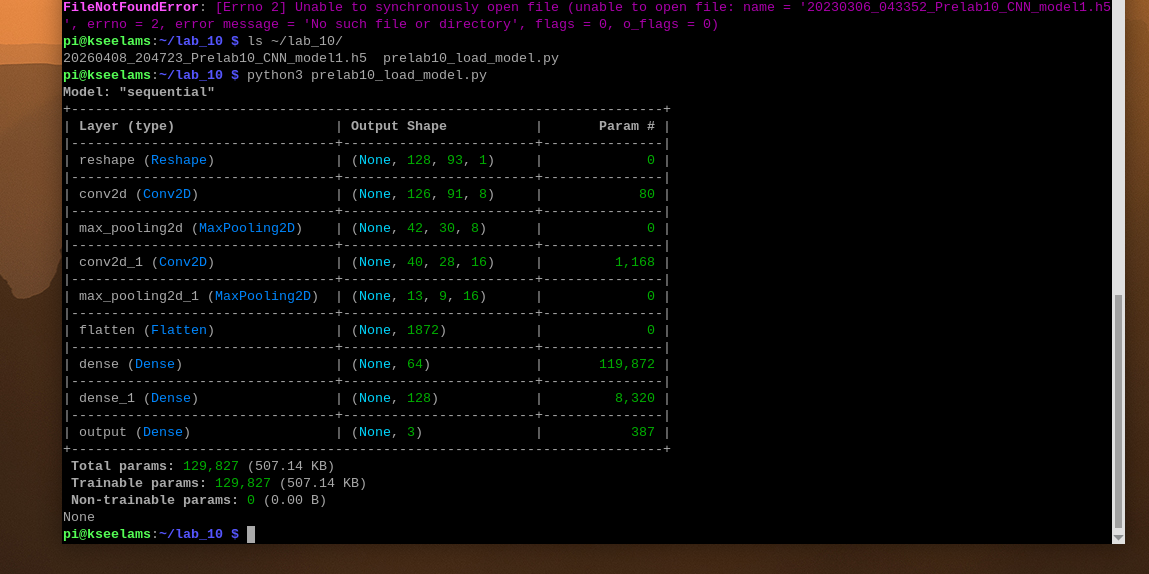

    ---




<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_update/Prelab10_fig13.png?raw=true" width="60%">

*Figure 13 Check the model summary*

## 3.3 Preparing implementation on Raspberry Pi

In Lab 10, to implement the CNN model on Raspberry Pi, **TensorFlow Lite** will be used. The TensorFlow Lite is a special feature and mainly designed for embedded and edge devices such as mobile, MCU, edge computer, and so on. It uses a custom memory allocator for execution latency and minimum load. Please go to [TensorFlow Lite](https://www.tensorflow.org/lite/guide) and look over it. We will use [TensorFlow Lite Interpreter API](https://www.tensorflow.org/api_docs/python/tf/lite/Interpreter).

As in the data collection via MTConnect sound stream for the training dataset, we will use the same sound sensor data flow for real-time implementation. By performing Task 3.3, come up with your monitoring system, logic, data flow, and so on so that you can realize the sound recognition of the operational state of the vacuum pump for real-time web-based monitoring.

### Task 3.3


Considering the requirement below, describe the data flow pipeline (system configuration) and software you need to use.
  
  * Sensor: Internal sound sensor (Stethoscope + microphone)
  * Target machine: Vacuum pump
  * Middleware 1 (server side, for sound stream): MTConnect
  * Middleware 2 (Raspberry Pi side, for taking monitoring items): MTConnect
  * Database: MySQL
  * Visualization: Grafana
  * Monitoring target(s):
    * Operational state of the machine (Event, OFF/ON-airleaking/ON-vacuum)
    * Sound level of the machine (Sample, dB unit)





---

he vacuum pump's vibration is captured by the stethoscope/microphone sensor and streamed as 16-bit integer audio at 48 kHz via an MTConnect server (mepotrb16.ecn.purdue.edu:5001). The Raspberry Pi acts as the edge computing node — it runs an MTConnect client that periodically fetches 1 second of audio via HTTP /current, normalizes and reshapes the raw samples, then feeds them into the CNN model for classification. The model outputs one of three operational states: OFF, ON-airleaking, or ON-vacuum (Event type). In parallel, the RMS amplitude is computed and converted to dB (Sample type). Both values are written to a MySQL database as time-series records. Grafana queries MySQL and displays the operational state and sound level on a real-time web dashboard.

Monitoring targets:

- Operational state > EVENT type, values: OFF / ON-airleaking / ON-vacuum
- Sound level > SAMPLE type, unit: dB

---


### Task 3.4

Using the MTConnect sound stream information given below, create a Python code to take current 1 second data to ingest them to the CNN model.

  * Server domain: mepotrb16.ecn.purdue.edu
  * MTConnect port: 5001
  * Device.xml (probe) info is below.
  * Measurement format: 16 Int (signed)

```
<?xml version="1.0" encoding="UTF-8"?>
<MTConnectDevices xmlns:m="urn:mtconnect.org:MTConnectDevices:1.1" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns="urn:mtconnect.org:MTConnectDevices:1.1" xsi:schemaLocation="urn:mtconnect.org:MTConnectDevices:1.1 http://www.mtconnect.org/schemas/MTConnectDevices_1.1.xsd">
	<Header creationTime="2010-03-04T18:44:40+00:00" sender="localhost" instanceId="1267728234" bufferSize="131072" version="1.1"/>
	<Devices>
		<Device id="sound1" name="sound1" uuid="sound1">
            <Description>ME597 Seound sensor at vacuum pump</Description>
			<DataItem category="SAMPLE" id="sensor1" name="sensor1" representation="TIME_SERIES" type="DISPLACEMENT" sampleRate="48000"/>
		</Device>
	</Devices>
</MTConnectDevices>
```

  * A current response is below.

```
<?xml version="1.0" encoding="UTF-8"?>
<MTConnectStreams xmlns:m="urn:mtconnect.org:MTConnectStreams:1.4" xmlns="urn:mtconnect.org:MTConnectStreams:1.4" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="urn:mtconnect.org:MTConnectStreams:1.4 http://schemas.mtconnect.org/schemas/MTConnectStreams_1.4.xsd">
  <Header creationTime="2023-03-08T06:48:37Z" sender="lamm-UltraPoint" instanceId="1676323553" version="1.4.0.10" bufferSize="8192" nextSequence="45341335" firstSequence="45333143" lastSequence="45341334"/>
  <Streams>
    <DeviceStream name="sound1" uuid="sound1">
      <ComponentStream component="Device" name="sound1" componentId="sound1">
        <Samples>
          <DisplacementTimeSeries dataItemId="sensor1" timestamp="2023-03-08T06:48:37.274686Z" name="sensor1" sequence="45341334" sampleCount="2048" sampleRate="48000">-217 -213 -241 -203 -192 -221 -173 -176 -175 -160 -162 -165 -173 -164 -180 -182 -164 -146 -139 -154 -184 -184 -146 -122 -112 -89 -117 -134 -99 -129 -175 -182 -153 -159 -169 -157 -153 -161 -160 -133 -157 -175 -171 -178 -175 -177 -161 -174 -190 -186 -206 -223 -190 -172 -204 -190 -200 -220 -223 -232 -248 -252 -253 -252 -227 -202 -194 -193 -184 -188 -199 -213 -213 -210 -222 -205 -191 -171 -167 -156 -161 -166 -164 -180 -192 -185 -180 -169 -207 -229 -215 -205 -182 -174 -191 -193 -194 -200 -193 -215 -209 -186 -158 -152 -174 -149 -133 -153 -147 -132 -88 -106 -120 -137 -147 -159 -146 -195 -195 -176 -176 -209 -211 -201 -199 -197 -215 -203 -213 -188 -176 -180 -193 -209 -205 -232 -205 -202 -174 -155 -154 -165 -160 -178 -172 -202 -172 -184 -214 -204 -208 -212 -197 -182 -176 -184 -208 -202 -188 -195 -207 -210 -217 -242 -200 -233 -227 -200 -181 -174 -190 -185 -201 -174 -211 -209 -222 -203 -170 -200 -196 -207 -203 -191 -189 -167 -151 -154 -153 -159 -165 -138 -143 -131 -142 -131 -110 -110 -103 -134 -128 -165 -149 -113 -122 -119 -100 -125 -122 -116 -110 -141 -119 -128 -144 -134 -137 -137 -154 -148 -159 -153 -121 -101 -73 -93 -77 -99 -101 -126 -113 -119 -110 -121 -111 -122 -117 -109 -92 -126 -161 -128 -76 -75 -53 -70 -74 -55 -77 -94 -119 -137 -184 -175 -150 -130 -178 -182 -204 -228 -219 -203 -173 -172 -183 -173 -168 -202 -197 -199 -218 -217 -192 -204 -196 -213 -224 -211 -215 -206 -277 -317 -307 -287 -288 -257 -260 -291 -288 -289 -298 -326 -321 -295 -307 -284 -279 -317 -328 -301 -305 -297 -296 -311 -306 -343 -345 -318 -287 -290 -299 -331 -334 -312 -304 -318 -330 -322 -306 -308 -311 -279 -270 -263 -250 -277 -305 -300 -317 -313 -325 -304 -280 -283 -319 -317 -352 -335 -321 -273 -289 -300 -279 -266 -281 -263 -241 -243 -223 -222 -233 -200 -203 -186 -175 -190 -174 -161 -163 -161 -150 -141 -157 -160 -171 -213 -230 -219 -190 -176 -182 -189 -177 -158 -172 -165 -155 -155 -143 -137 -156 -146 -123 -173 -153 -184 -220 -203 -230 -272 -222 -217 -222 -201 -203 -164 -191 -183 -199 -177 -152 -175 -146 -155 -151 -171 -175 -137 -137 -84 -86 -83 -101 -81 -46 -58 -64 -103 -89 -104 -88 -103 -95 -70 -67 -60 -105 -97 -110 -92 -94 -108 -99 -119 -104 -154 -128 -112 -129 -138 -162 -165 -178 -159 -132 -148 -102 -78 -62 -65 -61 -61 -27 -4 -26 -19 16 58 63 69 64 22 -18 -59 -49 -52 -57 -54 -65 -84 -58 -37 -33 -37 -51 -51 -44 -96 -93 -52 -81 -53 -47 -26 -8 0 -6 -22 16 46 -10 0 21 32 33 57 34 55 78 -4 16 10 7 20 23 6 24 34 50 74 92 44 92 103 124 138 161 202 238 239 211 218 196 172 159 164 145 159 158 127 117 114 97 69 34 43 45 65 91 66 42 44 70 86 94 89 87 79 86 91 126 160 172 183 165 168 180 165 168 177 188 180 189 197 209 218 192 204 169 169 191 210 203 223 230 249 232 243 231 212 230 220 216 235 281 279 268 240 249 266 282 312 340 338 343 319 299 301 289 259 280 280 288 300 300 290 309 301 284 300 278 272 260 268 233 253 268 265 273 245 263 246 227 195 216 235 207 175 199 185 164 173 154 179 204 226 230 225 225 187 180 169 167 134 169 184 169 168 145 123 135 179 158 147 134 152 149 123 158 140 157 141 126 129 139 176 169 172 195 204 207 179 191 190 193 186 170 168 156 170 166 152 142 130 146 117 108 90 102 96 88 63 54 54 68 67 54 54 46 30 61 63 106 91 111 96 79 36 61 89 94 81 54 72 68 98 82 84 92 83 59 69 71 86 71 111 118 109 90 77 11 -46 -78 -82 -83 -58 -20 -25 -43 -57 -9 -2 10 -25 -31 -20 -34 -42 -42 -70 -68 -39 -64 -65 -57 -61 -82 -64 -70 -50 -46 -47 -38 -5 -1 0 -7 -33 -27 -15 -36 -14 -7 16 15 -19 8 -9 -10 -12 12 48 39 27 8 14 8 0 25 40 26 32 39 54 53 34 -3 5 20 20 8 3 11 7 15 22 -7 -4 -30 -45 -46 -49 -22 -3 -5 6 60 76 82 69 59 59 40 41 45 36 49 52 78 71 66 75 83 78 91 121 127 110 100 67 60 -9 -20 -23 -2 5 33 68 65 45 32 59 74 74 93 100 94 80 67 77 83 72 79 88 68 79 107 80 95 90 60 63 63 44 41 75 46 55 36 32 56 33 27 40 41 42 26 74 68 104 82 101 88 83 103 128 144 150 154 118 124 106 72 105 102 121 117 120 115 98 122 107 141 144 174 138 154 180 141 161 168 216 209 224 206 215 214 215 227 203 244 245 234 234 241 238 242 252 234 245 223 196 199 182 174 185 180 190 174 187 195 220 193 188 164 158 161 140 159 147 108 128 86 97 129 136 104 115 139 146 153 121 75 105 104 105 107 87 104 131 135 145 146 141 159 129 161 145 124 128 119 120 100 122 165 174 147 165 168 172 175 182 175 174 146 136 120 140 155 164 148 155 146 128 115 100 119 98 107 136 138 131 140 154 154 129 93 84 100 124 107 106 111 107 119 109 122 124 122 139 146 148 174 164 141 169 162 141 158 172 188 185 193 202 188 164 163 209 184 176 164 140 115 78 93 104 56 29 25 27 38 54 58 53 75 82 68 32 24 21 -41 -105 -108 -100 -103 -110 -96 -100 -106 -103 -103 -126 -126 -111 -87 -68 -93 -110 -158 -174 -148 -144 -158 -137 -117 -145 -131 -127 -107 -125 -174 -167 -170 -154 -134 -117 -150 -129 -113 -120 -113 -121 -107 -110 -103 -84 -87 -128 -120 -81 -109 -92 -127 -151 -144 -136 -123 -135 -146 -144 -152 -131 -136 -90 -53 -41 -39 -6 -5 -39 -27 -17 23 16 26 14 -12 14 2 16 3 29 27 25 9 7 8 -9 28 4 25 29 11 21 4 -1 -13 -32 -50 -36 -14 -14 -47 -5 15 -7 -9 -4 7 46 62 48 69 94 100 90 95 96 128 112 73 93 131 122 131 151 156 146 141 134 115 123 114 122 138 147 160 172 161 156 158 160 186 180 180 207 237 226 214 173 186 215 197 185 170 172 163 154 147 161 160 187 209 219 235 222 230 248 251 275 268 241 258 233 221 226 245 220 206 241 237 264 258 227 236 222 189 169 171 158 149 164 158 151 169 188 195 198 194 198 189 217 228 228 241 212 232 258 290 286 261 228 234 220 203 226 246 246 255 224 231 238 251 262 253 284 281 310 304 299 301 295 278 296 290 294 274 298 281 278 278 270 283 291 279 292 305 319 325 299 282 301 252 294 281 293 288 264 266 265 199 267 278 289 320 315 310 306 278 280 275 298 295 316 287 280 296 290 293 325 311 264 305 307 314 331 339 371 358 370 356 337 326 324 332 345 397 360 360 320 308 371 335 347 334 328 283 253 275 264 269 273 332 317 334 318 319 349 335 364 370 398 375 321 299 286 304 287 289 264 267 274 236 237 242 269 254 251 242 254 217 232 276 257 281 302 301 305 260 239 295 321 326 317 295 324 342 322 278 282 306 299 311 319 338 330 296 254 299 338 341 364 377 364 354 362 336 328 297 297 295 290 300 307 344 325 306 316 319 288 284 263 266 250 245 273 285 260 266 263 257 254 265 306 266 248 260 216 225 214 194 177 192 203 193 159 145 117 99 105 127 125 113 115 135 164 171 176 170 181 194 195 173 126 118 129 134 159 192 212 210 198 157 154 117 103 96 51 52 42 -15 -16 -40 -30 8 35 15 -6 -2 12 -5 11 23 34 2 6 15 4 28 44 40 31 53 63 53 66 51 45 20 -12 12 11 -20 3 20 0 1 22 21 16 20 26 -3 2 -6 -5 20 26 3 2 6 16 23 19 14 40 49 21 -10 2 -26 -21 -11 -23 -8 -27 -22 -44 -34 -30 -38 -26 -41 -26 -53 -10 16 -13 -14 -2 -10 -46 -30 -37 -9 -17 6 -4 -29 -44 -42 -28 -17 -15 -30 -37 -1 -11 2 -5 26 19 38 41 7 3 3 -1 -3 -6 -18 -38 -40 -47 -30 -59 -64 -56 -53 -56 -40 16 19 9 -8 0 -10 -17 -19 6 36 20 47 9 -24 -9 -23 -53 -52 -16 -29 -28 -46 -21 -18 -22 -40 -40 -27 -53 -62 -30 -25 -68 -92 -111 -113 -99 -95 -101 -97 -87 -82 -58 -88 -73 -98 -95 -82 -81 -93 -83 -112 -56 -49 -49 -20 -25 -40 -21 -42 -42 -30 -45 -45 -60 -92 -92 -73 -66 -37 -44 -43 -26 -28 18 44 15 -2 -34 -36 -19 -34 -27 16 5 34 34 0 -7 -22 -19 -38 1 8 11 -12 3 1 -17 -14 -42 -74 -84 -63 -74 -49 0 3 31 37 36 54 46 93 104 96 84 64 47 16 -3 -6 5 2 -36 -35 -30 -28 -49 -60 -80 -94 -96 -83 -69 -49 -50 -61 -69 -43 -65 -74 -64 -83 -78 -29 -30 -14 -29 -17 0 17 18 14 11 23 9 -14 17 -15 21 8 -36 6 2 -22 -5 -14 -13 0 -36 -33 -42 -26 -25 -15 -21 -32 -26 -45 -47 -76 -85 -83 -51 -53 -53 -34 -45 -58 -43 -21 1 7 8 -16 4 4 2 -6 -26 -39 -67 -56 -74 -89 -88 -108 -89 -101 -87 -77 -72 -84 -101 -116 -131 -66 -96 -85 -74 -87 -122 -141 -117 -146 -145 -143 -168 -207 -219 -241 -252 -250 -233 -213 -189 -172 -158 -128 -137 -179 -158 -153 -170 -192 -183 -205 -212 -199 -226 -236 -274 -286 -323 -291 -259 -278 -261 -266 -241 -182 -190 -231 -219 -202 -189 -176 -144 -146 -159 -156 -188 -168 -169 -191 -195 -186 -168 -165 -142 -144 -152 -118 -63 -74 -86 -90 -109 -101 -105 -81 -84 -85 -59 -71 -93 -91 -77 -96 -72 -49 -69 -30 -40 -15 6 -18 -7 -6 -9 -10 -29 -16 0 18 3 -24 -28 -20 -17 -30 -43 -50 -37 -44 -44 -28 -35 -41 -33 -61 -46 -48 -93 -120 -160 -155 -172 -165 -186 -200 -173 -156 -98 -106 -88 -81 -84 -57 -102 -97 -98 -82 -71 -51 -64 -59 -66 -55 -13 -28 -25 22 -12 11 -1 14 32 38 42 24 35 40 76 82 91 110 100 98 92 86 74 82 74 52 49 40 59 70 51 56 60 80 61 64 79 </DisplacementTimeSeries>
        </Samples>
        <Events>
          <AssetChanged dataItemId="sound1_asset_chg" timestamp="2023-02-13T21:25:53.789634Z" sequence="2" assetType="">UNAVAILABLE</AssetChanged>
          <AssetRemoved dataItemId="sound1_asset_rem" timestamp="2023-02-13T21:25:53.789634Z" sequence="3" assetType="">UNAVAILABLE</AssetRemoved>
          <Availability dataItemId="sound1_avail" timestamp="2023-02-13T21:45:55.179863Z" sequence="27376">AVAILABLE</Availability>
        </Events>
      </ComponentStream>
    </DeviceStream>
  </Streams>
</MTConnectStreams>
```



---

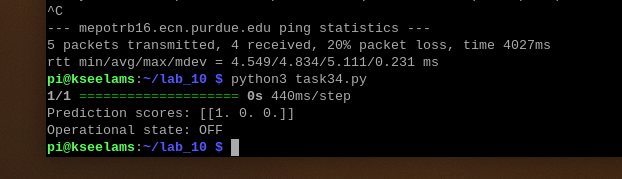

---



In [ ]:
import requests
import numpy as np
import tensorflow as tf
import librosa
from xml.etree import ElementTree as ET

# --- Config ---
SERVER = "http://mepotrb16.ecn.purdue.edu:5001"
SAMPLE_RATE = 48000
MODEL_PATH = '20260408_204723_Prelab10_CNN_model1.h5'
LABELS = ['OFF', 'ON-airleaking', 'ON-vacuum']

# --- Load model ---
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# --- Fetch 1 second of audio from MTConnect ---
def fetch_audio():
    response = requests.get(f"{SERVER}/current", timeout=10)
    root = ET.fromstring(response.content)
    samples = root.findall('.//{urn:mtconnect.org:MTConnectStreams:1.4}DisplacementTimeSeries')
    if not samples:
        samples = root.findall('.//DisplacementTimeSeries')
    values = np.array([int(x) for x in samples[0].text.strip().split()], dtype=np.float32)
    return values

# --- Preprocess: raw 16-bit int audio -> mel spectrogram (128, 93) ---
def preprocess(audio):
    audio = audio / 32768.0  # normalize to [-1, 1]
    # Pad or trim to exactly 1 second (48000 samples)
    if len(audio) >= SAMPLE_RATE:
        audio = audio[:SAMPLE_RATE]
    else:
        audio = np.pad(audio, (0, SAMPLE_RATE - len(audio)))
    # Mel spectrogram matching model input shape (128, 93)
    mel = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] >= 93:
        mel_db = mel_db[:, :93]
    else:
        mel_db = np.pad(mel_db, ((0, 0), (0, 93 - mel_db.shape[1])))
    return mel_db.reshape(1, 128, 93, 1)

# --- Run inference ---
audio_raw = fetch_audio()
audio_input = preprocess(audio_raw)
predictions = model.predict(audio_input)
predicted_class = np.argmax(predictions, axis=1)[0]

print(f"Prediction scores: {predictions}")
print(f"Operational state: {LABELS[predicted_class]}")

## 3.4 (Optional) Further reading

The list below is recent related research using the internal sound sensor and sound monitoring/recognition published in academic journals. If you are interested in detail, please go through them.


*   Yun, H., Kim, H., Kim, E. and Jun, M.B., 2020. Development of internal sound sensor using stethoscope and its applications for machine monitoring. Procedia Manufacturing, 48, pp.1072-1078. (https://doi.org/10.1016/j.promfg.2020.05.147)
*   Kim, E., Yun, H., Jun, M.B.G., Kim, K. and Cha, S.W., 2021, June. Multiple Sound Sensors And Fusion In Modern CNN-Based Machine State Prediction. In International Manufacturing Science and Engineering Conference (Vol. 85062, p. V001T05A017). American Society of Mechanical Engineers. (https://doi.org/10.1115/MSEC2021-64036)
*   Yun, H., Kim, H., Jeong, Y.H. and Jun, M.B., 2023. Autoencoder-based anomaly detection of industrial robot arm using stethoscope based internal sound sensor. Journal of Intelligent Manufacturing, 34(3), pp.1427-1444. (https://doi.org/10.1007/s10845-021-01862-4)
*   Kim, E., Yun, H., Araujo, O.C., and Jun, M.B.G., 2023, Sound Recognition based on Convolutional Neural Network for Real-Time Cutting State Monitoring of Tube Cutting Machine. International Journal of Precision Engineering and Manufacturing-Smart Technology, Vol. 1, No. 1, pp.1-18. (https://doi.org/10.57062/ijpem-st.2022.0038)



<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)
